# Quantile Regression with ε-tolerance
[![Slides](https://img.shields.io/badge/🦌-ReHLine-blueviolet)](https://rehline-python.readthedocs.io/en/latest/)

Quantile Regression with ε-tolerance solves the following optimization problem:

$$
\min_{\beta \in \mathbb{R}^d}
\sum_{i=1}^n
\left(\rho_{\kappa}\!\left(y_i - \mathbf{x}_i^\top \beta\right)-\epsilon\right)_+
+ \frac{\lambda}{2}\|\beta\|^2
$$

where

- $\rho_{\kappa}(r)=r\cdot\big(\kappa-\mathbf{1}(r<0)\big)$ is the check loss (quantile loss),
- $\mathbf{x}_i\in\mathbb{R}^d$ is a feature vector,
- $y_i\in\mathbb{R}$ is a continuous response variable,
- $\kappa\in(0,1)$ is the quantile level,
- $\epsilon\ge 0$ is the tolerance parameter.

> **Note.** Since the check loss is a plq function, we can optimize it using `rehline.plq_Ridge_Regressor`. 
> Moreover, this wrapper adapts the `plqERM_Ridge` into a regressor, compatible with the scikit-learn API.

In [1]:
## install rehline
%pip install rehline -q

In [2]:
# Simulate Data
import numpy as np

np.random.seed(42)
n = 2000
x = np.random.randn(n)
noise = np.random.randn(n) * (0.3 + 0.5 * np.abs(x))
y = 2 * x + noise
X = x.reshape(-1, 1)

In [3]:
from rehline import plq_Ridge_Regressor

# Check Loss with epsilon-tolerance
clf = plq_Ridge_Regressor(loss={"name": "check_eps", "qt": 0.9, "epsilon": 0.1}, C=10.0 / n)
clf.fit(X=X, y=y)

plq_Ridge_Regressor(C=0.005,
                    loss={'epsilon': 0.1, 'name': 'check_eps', 'qt': 0.9})

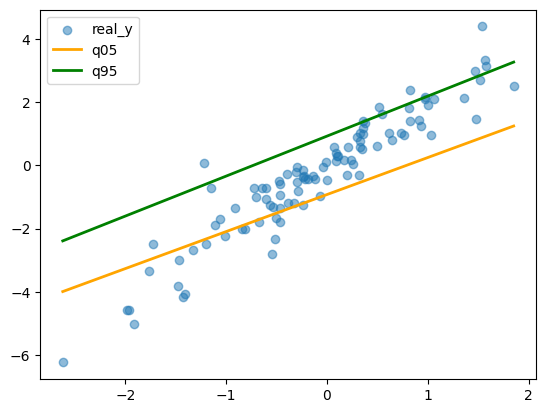

In [4]:
## plot Check Loss with epsilon results
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", "is_categorical_dtype")

# Parameters
epsilon = 0.3

# Fit Check Loss with epsilon (two quantiles)
clf05 = plq_Ridge_Regressor(loss={"name": "check_eps", "qt": 0.05, "epsilon": epsilon}, C=10.0 / n)
clf05.fit(X=X, y=y)

clf95 = plq_Ridge_Regressor(loss={"name": "check_eps", "qt": 0.95, "epsilon": epsilon}, C=10.0 / n)
clf95.fit(X=X, y=y)

# Plot
n_sample = 100
X_sample, y_sample = X[:n_sample], y[:n_sample]
q05_sample = clf05.predict(X_sample)
q95_sample = clf95.predict(X_sample)

# sort by x0
sort_idx = np.argsort(X_sample[:, 0])
x0_sorted = X_sample[sort_idx, 0]
y_sorted = y_sample[sort_idx]
q05_sorted = q05_sample[sort_idx]
q95_sorted = q95_sample[sort_idx]

plt.scatter(x0_sorted, y_sorted, alpha=0.5, label="real_y")
plt.plot(x0_sorted, q05_sorted, "orange", linewidth=2, label="q05")
plt.plot(x0_sorted, q95_sorted, "green", linewidth=2, label="q95")
plt.legend()
plt.show()

Epsilon creates a tolerance zone where small residuals incur zero loss, so the model only penalizes deviations exceeding this threshold.

This produces tighter quantile intervals and more robust estimates, suitable for scenarios where small errors are acceptable but large deviations matter.

In [5]:
## Comparison: Original QR vs Check Loss with epsilon
import warnings

import matplotlib.pyplot as plt
import numpy as np

from rehline import plq_Ridge_Regressor

warnings.filterwarnings("ignore", "is_categorical_dtype")

# Parameters
epsilon = 0.2

# Fit original QR
clf_qr05 = plq_Ridge_Regressor(loss={"name": "QR", "qt": 0.05}, C=10.0 / n)
clf_qr05.fit(X=X, y=y)

clf_qr95 = plq_Ridge_Regressor(loss={"name": "QR", "qt": 0.95}, C=10.0 / n)
clf_qr95.fit(X=X, y=y)

# Fit Check Loss with epsilon
clf_eps05 = plq_Ridge_Regressor(loss={"name": "check_eps", "qt": 0.05, "epsilon": epsilon}, C=10.0 / n)
clf_eps05.fit(X=X, y=y)

clf_eps95 = plq_Ridge_Regressor(loss={"name": "check_eps", "qt": 0.95, "epsilon": epsilon}, C=10.0 / n)
clf_eps95.fit(X=X, y=y)

plq_Ridge_Regressor(C=0.005,
                    loss={'epsilon': 0.2, 'name': 'check_eps', 'qt': 0.95})

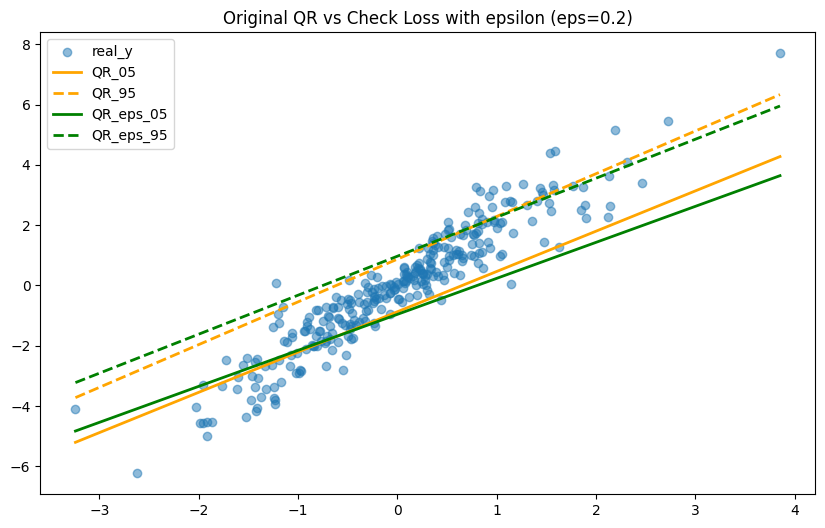

In [6]:
# Plot
n_sample = 300
X_sample, y_sample = X[:n_sample], y[:n_sample]

sort_idx = np.argsort(X_sample[:, 0])
x0_sorted = X_sample[sort_idx, 0]
y_sorted = y_sample[sort_idx]

qr05_sorted = clf_qr05.predict(X_sample)[sort_idx]
qr95_sorted = clf_qr95.predict(X_sample)[sort_idx]
eps05_sorted = clf_eps05.predict(X_sample)[sort_idx]
eps95_sorted = clf_eps95.predict(X_sample)[sort_idx]

plt.figure(figsize=(10, 6))
plt.scatter(x0_sorted, y_sorted, alpha=0.5, label="real_y")
plt.plot(x0_sorted, qr05_sorted, "orange", linewidth=2, label="QR_05")
plt.plot(x0_sorted, qr95_sorted, "orange", linewidth=2, linestyle="--", label="QR_95")
plt.plot(x0_sorted, eps05_sorted, "green", linewidth=2, label="QR_eps_05")
plt.plot(x0_sorted, eps95_sorted, "green", linewidth=2, linestyle="--", label="QR_eps_95")
plt.legend()
plt.title(f"Original QR vs Check Loss with epsilon (eps={epsilon})")
plt.show()

## With Pipeline
`plq_Ridge_Regressor` can be integrated into a scikit-learn Pipeline to streamline preprocessing including scaling.

In [7]:
# Simulate Data
import numpy as np

np.random.seed(42)
n = 2000
x = np.random.randn(n)
noise = np.random.randn(n) * (0.3 + 0.5 * np.abs(x))
y = 2 * x + noise
X = x.reshape(-1, 1)

In [8]:
# Fit Check Loss with epsilon (two quantiles)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from rehline import plq_Ridge_Regressor

epsilon = 0.3

pipe5 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("reg", plq_Ridge_Regressor(loss={"name": "check_eps", "qt": 0.05, "epsilon": epsilon}, C=10.0 / n)),
    ]
)
pipe5.fit(X=X, y=y)

pipe95 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("reg", plq_Ridge_Regressor(loss={"name": "check_eps", "qt": 0.95, "epsilon": epsilon}, C=10.0 / n)),
    ]
)
pipe95.fit(X=X, y=y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 plq_Ridge_Regressor(C=0.005,
                                     loss={'epsilon': 0.3, 'name': 'check_eps',
                                           'qt': 0.95}))])

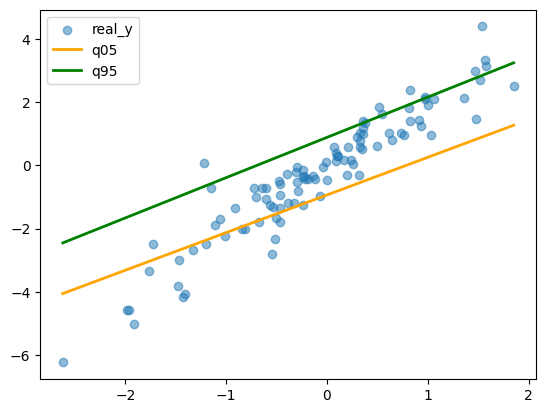

In [9]:
# Plot
import matplotlib.pyplot as plt
import numpy as np

n_sample = 100
X_sample, y_sample = X[:n_sample], y[:n_sample]
q05_sample = pipe5.predict(X_sample)
q95_sample = pipe95.predict(X_sample)

sort_idx = np.argsort(X_sample[:, 0])
x0_sorted = X_sample[sort_idx, 0]
y_sorted = y_sample[sort_idx]
q05_sorted = q05_sample[sort_idx]
q95_sorted = q95_sample[sort_idx]

plt.scatter(x0_sorted, y_sorted, alpha=0.5, label="real_y")
plt.plot(x0_sorted, q05_sorted, color="orange", linewidth=2, label="q05")
plt.plot(x0_sorted, q95_sorted, color="green", linewidth=2, label="q95")
plt.legend()
plt.show()

## Hyperparameter Tuning with GridSearchCV

Due to its compatibility with the scikit-learn API, `GridSearchCV` can be applied to determine the optimal hyperparameters for the ReHLine model.

In [10]:
import warnings

from sklearn.metrics import make_scorer, mean_pinball_loss
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings("ignore")

# Define the parameter grid to search
param_grid = {"reg__C": [1.0 / n, 10.0 / n, 100.0 / n]}

# Use pinball loss
scorer05 = make_scorer(mean_pinball_loss, alpha=0.05, greater_is_better=False)
scorer95 = make_scorer(mean_pinball_loss, alpha=0.95, greater_is_better=False)

# Create the GridSearchCV objects
grid_search5 = GridSearchCV(pipe5, param_grid, cv=5, scoring=scorer05)
grid_search95 = GridSearchCV(pipe95, param_grid, cv=5, scoring=scorer95)

grid_search5.fit(X, y)
grid_search95.fit(X, y)

# Print the best parameters and scores
print(f"Best Parameters (qt=0.05): {grid_search5.best_params_}")
print(f"Best CV Score (qt=0.05): {-grid_search5.best_score_:.4f}")

print(f"Best Parameters (qt=0.95): {grid_search95.best_params_}")
print(f"Best CV Score (qt=0.95): {-grid_search95.best_score_:.4f}")

Best Parameters (qt=0.05): {'reg__C': 0.05}
Best CV Score (qt=0.05): 0.0911
Best Parameters (qt=0.95): {'reg__C': 0.05}
Best CV Score (qt=0.95): 0.0931


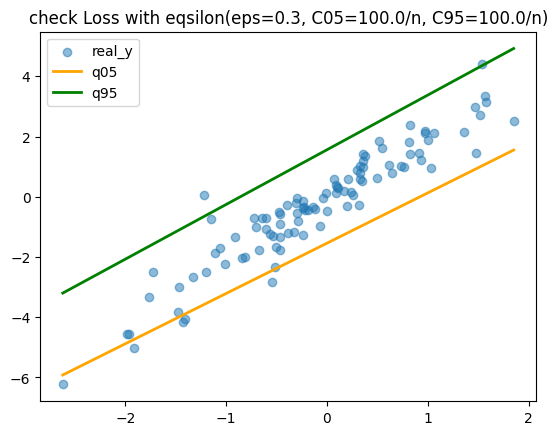

In [11]:
# Plot
n_sample = 100
X_sample, y_sample = X[:n_sample], y[:n_sample]
q05_sample = grid_search5.predict(X_sample)
q95_sample = grid_search95.predict(X_sample)

sort_idx = np.argsort(X_sample[:, 0])
x0_sorted = X_sample[sort_idx, 0]
y_sorted = y_sample[sort_idx]
q05_sorted = q05_sample[sort_idx]
q95_sorted = q95_sample[sort_idx]

plt.scatter(x0_sorted, y_sorted, alpha=0.5, label="real_y")
plt.plot(x0_sorted, q05_sorted, color="orange", linewidth=2, label="q05")
plt.plot(x0_sorted, q95_sorted, color="green", linewidth=2, label="q95")
plt.title(f"check Loss with eqsilon(eps={epsilon}, C05=100.0/n, C95=100.0/n)")
plt.legend()
plt.show()